In [7]:
# ============================================================
# Full notebook pipeline:
# MAE-by-k boxplot with outliers shown for k=2,3,4
# - only k=2 outliers are colored by tissue pair
# - k=3 and k=4 outliers are shown in neutral gray
# - optional annotation toggle for k=2 outliers only
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
import data_loading
import deconv_data
import deconv_model

from utils import (
    build_label_map,
    extract_sample_labels,
    build_centroids,
    apply_label_map,
    select_probes_from_centroids,
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
SPLIT_PATH = Path("/home/jullid/projects/mouse-DNA-project/results/deconvolution/split.json")

N_MIXTURES = 1000
K_MIN = 2
K_MAX = 4
MIXTURE_SEED = 123

# Toggle whether k=2 outlier points should have text labels next to them
ANNOTATE_K2_OUTLIERS = True

%matplotlib inline

# ------------------------------------------------------------
# Helper 1: rebuild the deconvolution benchmark in notebook
# ------------------------------------------------------------
def prepare_deconv_run_for_notebook(
    split_path: Path,
    k_min: int,
    k_max: int,
    n_mixtures: int = 1000,
    mixture_seed: int = 123,
):
    """
    Rebuild the deconvolution benchmark from scratch in the notebook.

    Steps:
    1. Load raw data
    2. Recover original tissue labels
    3. Remove excluded tissues
    4. Load saved reference/pool split
    5. Build reference centroids from reference samples only
    6. Rerun probe selection from the reference-only centroids
    7. Build W_masked from the selected probes
    8. Generate synthetic mixtures with requested k range
    9. Run NNLS deconvolution
    10. Compute per-mixture metrics
    """
    # Load raw methylation data
    df_raw, _, _, _ = data_loading.load_all()
    print(f"df_raw shape (probes x samples): {df_raw.shape}")

    # Build label map from merge groups
    label_map = build_label_map(data_loading.MERGE_GROUPS)

    # Extract original tissue labels from sample names
    original_labels_all = extract_sample_labels(df_raw)

    # Remove excluded tissues, matching project logic
    _, _ = apply_label_map(
        original_labels_all,
        label_map,
        excluded_tissues=data_loading.EXCLUDED_TISSUES,
    )
    keep_mask = ~original_labels_all.isin(data_loading.EXCLUDED_TISSUES)
    original_labels = original_labels_all[keep_mask]

    # Load saved reference/pool split
    reference_cols, pool_cols = deconv_data.load_split(split_path)

    # Build reference centroid matrix from reference split only
    df_merged_ref = build_centroids(
        df_raw=df_raw,
        sample_cols=reference_cols,
        original_labels=original_labels,
        merge_groups=data_loading.MERGE_GROUPS,
    )
    print(f"Reference centroid matrix shape: {df_merged_ref.shape}")

    # Rerun probe selection from reference-only centroids
    selected_probes = select_probes_from_centroids(df_merged_ref)
    print(f"Selected probes: {len(selected_probes)}")

    # Build reference matrix W
    W_masked = deconv_data.build_reference_matrix(
        df_raw=df_raw,
        reference_cols=reference_cols,
        original_labels=original_labels,
        selected_probes=selected_probes,
    )

    # Determine eligible tissues for mixture generation
    eligible_tissues = deconv_data.get_eligible_tissues(
        pool_cols=pool_cols,
        original_labels=original_labels,
        label_map=label_map,
        min_pool_replicates=config.DECONV_MIN_POOL_REPLICATES,
    )

    # Generate synthetic mixtures
    X_mixtures, df_proportions = deconv_data.generate_synthetic_mixtures(
        df_raw=df_raw,
        pool_cols=pool_cols,
        original_labels=original_labels,
        label_map=label_map,
        selected_probes=selected_probes,
        eligible_tissues=eligible_tissues,
        n_mixtures=n_mixtures,
        k_min=k_min,
        k_max=k_max,
        dirichlet_alpha=config.DECONV_DIRICHLET_ALPHA,
        random_state=mixture_seed,
    )

    # Run NNLS deconvolution
    df_estimated, residuals = deconv_model.deconvolve_batch(
        W_masked=W_masked,
        X_mixtures=X_mixtures,
    )

    # Compute per-mixture metrics
    df_mixture_metrics = deconv_model.compute_per_mixture_metrics(
        df_true=df_proportions,
        df_estimated=df_estimated,
    )

    return {
        "df_raw": df_raw,
        "original_labels": original_labels,
        "label_map": label_map,
        "reference_cols": reference_cols,
        "pool_cols": pool_cols,
        "df_merged_ref": df_merged_ref,
        "selected_probes": selected_probes,
        "W_masked": W_masked,
        "eligible_tissues": eligible_tissues,
        "X_mixtures": X_mixtures,
        "df_proportions": df_proportions,
        "df_estimated": df_estimated,
        "residuals": residuals,
        "df_mixture_metrics": df_mixture_metrics,
    }


# ------------------------------------------------------------
# Helper 2: build true tissue-pair labels for k=2 mixtures
# ------------------------------------------------------------
def build_k2_pair_labels(df_proportions: pd.DataFrame) -> pd.Series:
    """
    For each mixture with exactly 2 true components:
    - identify the two non-zero tissues
    - sort them alphabetically
    - join as 'tissueA__tissueB'
    """
    n_components = (df_proportions > 0).sum(axis=1)
    k2_ids = n_components[n_components == 2].index.tolist()

    pair_labels = {}
    for mix_id in k2_ids:
        true_row = df_proportions.loc[mix_id]
        active_tissues = true_row[true_row > 0].index.tolist()

        if len(active_tissues) != 2:
            continue

        pair_labels[mix_id] = "__".join(sorted(active_tissues))

    return pd.Series(pair_labels, name="tissue_pair")


# ------------------------------------------------------------
# Helper 3: standard boxplot outlier rule
# ------------------------------------------------------------
def find_boxplot_outliers(values: pd.Series):
    """
    Standard boxplot outlier rule:
    outlier if < Q1 - 1.5*IQR or > Q3 + 1.5*IQR
    """
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    is_outlier = (values < lower_bound) | (values > upper_bound)
    return lower_bound, upper_bound, is_outlier


# ------------------------------------------------------------
# Helper 4: plot same MAE-by-k boxplot as src, with outliers
# shown for k=2,3,4, but only k=2 colored by tissue pair
# ------------------------------------------------------------
def plot_mae_by_components_with_k2_colored_outliers_only(
    df_mixture_metrics: pd.DataFrame,
    df_proportions: pd.DataFrame,
    title: str = "MAE distribution by number of components",
    annotate_k2: bool = False,
):
    """
    Reproduce the same base boxplot structure/style as src/deconv_model.py,
    but:
    - overlay outliers for k=2, k=3, and k=4
    - only k=2 outliers are colored by tissue pair
    - k=3 and k=4 outliers are shown in neutral gray
    - optional annotation for k=2 outliers only
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    # SAME grouping structure as src code
    groups = df_mixture_metrics.groupby("n_components")["mae"]
    positions = sorted(groups.groups.keys())
    data = [groups.get_group(k).values for k in positions]

    # Same boxplot, but hide default outliers so we can overlay our own
    bp = ax.boxplot(
        data,
        positions=range(len(positions)),
        patch_artist=True,
        showfliers=False,
    )

    # Same box styling as src
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.7)

    # Build k=2 pair labels once
    k2_pair_labels = build_k2_pair_labels(df_proportions)

    # Build color map only for k=2 pairs
    unique_k2_pairs = sorted(k2_pair_labels.dropna().unique().tolist())
    palette = sns.color_palette("husl", n_colors=max(len(unique_k2_pairs), 1))
    pair_to_color = {pair: palette[i] for i, pair in enumerate(unique_k2_pairs)}

    rng = np.random.RandomState(42)

    # Overlay outliers for k=2,3,4
    for k in [2, 3, 4]:
        if k not in positions:
            print(f"No k={k} mixtures found, skipping.")
            continue

        k_metrics = df_mixture_metrics[df_mixture_metrics["n_components"] == k].copy()

        lower_bound, upper_bound, is_outlier = find_boxplot_outliers(k_metrics["mae"])
        k_outliers = k_metrics[is_outlier].copy()

        print(
            f"k={k} outlier threshold: < {lower_bound:.4f} or > {upper_bound:.4f} | "
            f"n_outliers = {len(k_outliers)}"
        )

        x_center = positions.index(k)

        # If k=2, attach tissue-pair labels and color by pair
        if k == 2:
            k_outliers = k_outliers.join(k2_pair_labels, how="left")

            for mix_id, row in k_outliers.iterrows():
                x = x_center + rng.uniform(-0.08, 0.08)
                y = row["mae"]
                pair = row["tissue_pair"]

                ax.scatter(
                    x,
                    y,
                    s=42,
                    color=pair_to_color.get(pair, "black"),
                    edgecolors="black",
                    linewidths=0.4,
                    alpha=0.9,
                    zorder=5,
                    label=pair,
                )

                if annotate_k2:
                    ax.text(
                        x + 0.015,
                        y,
                        pair,
                        fontsize=5,
                        va="center",
                    )

        # If k=3 or k=4, show outliers in neutral gray
        else:
            for _, row in k_outliers.iterrows():
                x = x_center + rng.uniform(-0.08, 0.08)
                y = row["mae"]

                ax.scatter(
                    x,
                    y,
                    s=36,
                    color="dimgray",
                    edgecolors="black",
                    linewidths=0.3,
                    alpha=0.8,
                    zorder=5,
                )

    # SAME axis style as src function
    ax.set_xticks(range(len(positions)))
    ax.set_xticklabels([f"k={k}" for k in positions])
    ax.set_xlabel("Number of tissue components")
    ax.set_ylabel("MAE")
    ax.set_title(title)

    # Deduplicate legend entries for k=2 only
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    uniq_handles = []
    uniq_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq_handles.append(h)
            uniq_labels.append(l)
            seen.add(l)

    if len(uniq_handles) > 0:
        ax.legend(
            uniq_handles,
            uniq_labels,
            title="k=2 tissue pair",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
            fontsize=7,
            title_fontsize=8,
            frameon=True,
        )

    plt.tight_layout()
    plt.show()



In [3]:

# ============================================================
# Run the full notebook workflow
# ============================================================

# Step 1: rerun the benchmark from scratch in notebook
task2 = prepare_deconv_run_for_notebook(
    split_path=SPLIT_PATH,
    k_min=K_MIN,
    k_max=K_MAX,
    n_mixtures=N_MIXTURES,
    mixture_seed=MIXTURE_SEED,
)


df_raw shape (probes x samples): (288655, 268)
Excluded 20 samples from: {'Sciatic_Nerve', 'Mammary_Glands', 'Optic_Nerve'}
Remaining samples: 247

Sample counts per merged tissue class:
merged_tissue
Adrenal                      6
Bile_Duct                    6
Blood_Spleen_Thymus         30
Brain_Cortex_Subcortical    25
Cerebellum                   9
Colon                       11
Diaphragm                    6
Eye_Retina                  17
Femur                       10
Heart                       10
Kidney                      12
Liver                       26
Lung                        10
Pancreas                     7
Skin_Ears_Tail              31
Spinal_Cord                  6
Stomach                      5
Testis                      10
Urinary_Bladder              6
Uterus                       4
Name: count, dtype: int64
Loaded split from /home/jullid/projects/mouse-DNA-project/results/deconvolution/split.json
  Reference fraction: 0.5
  Split seed: 42
  Reference: 119 sa

In [4]:

# Step 2: quick summary table
print("\nMAE summary by number of components:")
print(task2["df_mixture_metrics"].groupby("n_components")["mae"].describe())



MAE summary by number of components:
              count      mean       std       min       25%       50%  \
n_components                                                            
2             323.0  0.009649  0.007509  0.000019  0.004406  0.008008   
3             306.0  0.009392  0.006037  0.000416  0.005165  0.007982   
4             371.0  0.010798  0.005820  0.001964  0.006477  0.009388   

                   75%       max  
n_components                      
2             0.012922  0.051710  
3             0.012717  0.032528  
4             0.014031  0.035060  


k=2 outlier threshold: < -0.0084 or > 0.0257 | n_outliers = 13
k=3 outlier threshold: < -0.0062 or > 0.0240 | n_outliers = 10
k=4 outlier threshold: < -0.0049 or > 0.0254 | n_outliers = 10


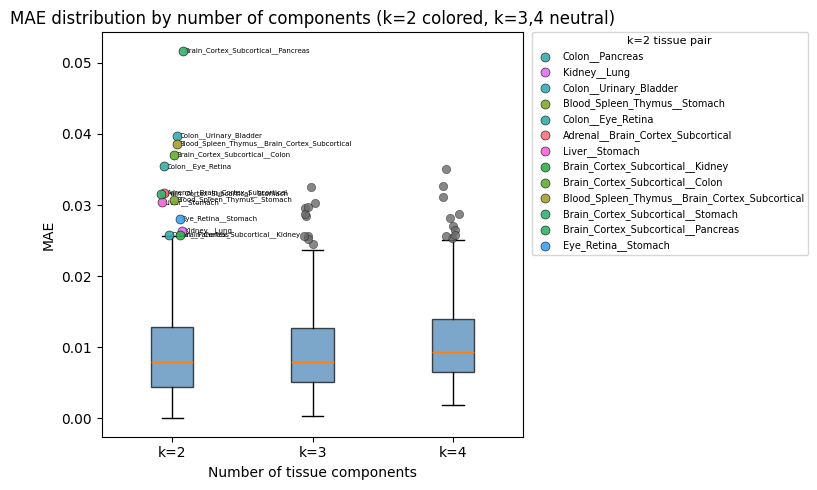

In [9]:

# Step 3: reproduce the MAE-by-k figure with:
# - colored outliers for k=2 only
# - neutral outliers for k=3 and k=4
# - optional k=2 text labels
plot_mae_by_components_with_k2_colored_outliers_only(
    df_mixture_metrics=task2["df_mixture_metrics"],
    df_proportions=task2["df_proportions"],
    title="MAE distribution by number of components (k=2 colored, k=3,4 neutral)",
    annotate_k2=True,
)